In [10]:
import pandas as pd


FOLDER = '01_Timeseries_Sensors'

PATH = f"{FOLDER}/Startup/batch_dist_binary_ethanol+propan-2-ol/operating_point_002/train_normal_experiment_002.csv"

experiment = pd.read_csv(f"../data/raw/{PATH}")

In [20]:
print(experiment.columns.tolist())

['Time', 'LS701', 'LS702', 'T701', 'T702', 'T703', 'T704', 'T706', 'T708', 'T709', 'T711', 'T712', 'T705', 'FT703', 'FT704', 'PDI701', 'PDI702', 'PY23', 'FYI702']


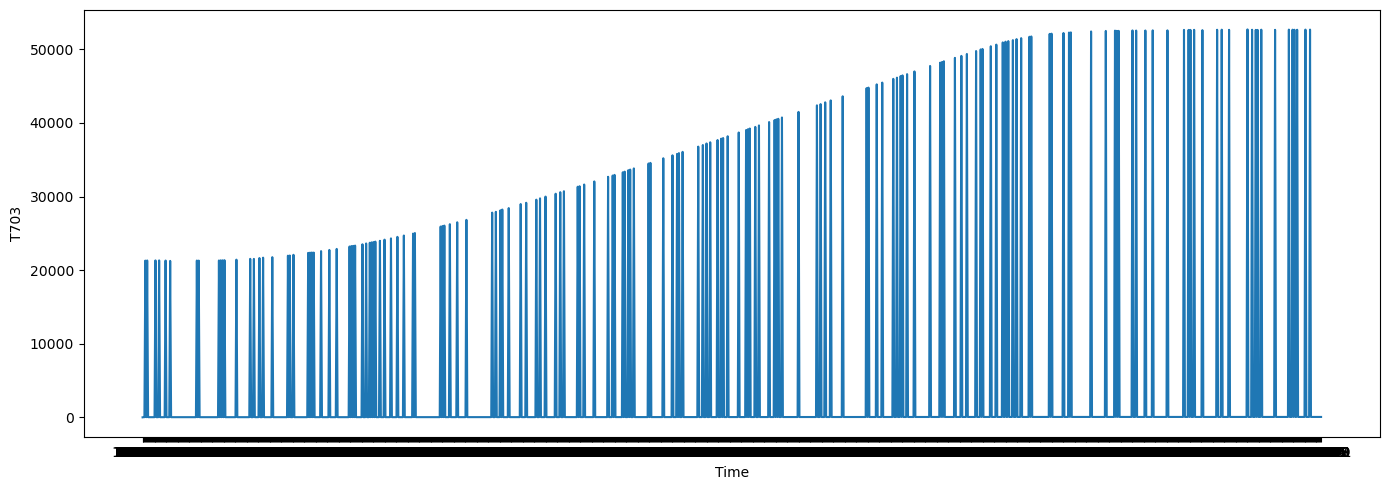

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

y = "T703"                                   # or any other sensor, actuator, or anomaly label

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=experiment,
    x="Time",
    y=y,
    ax=ax
)


ax.set_xlabel("Time")
ax.set_ylabel(y)
plt.tight_layout()
plt.show()

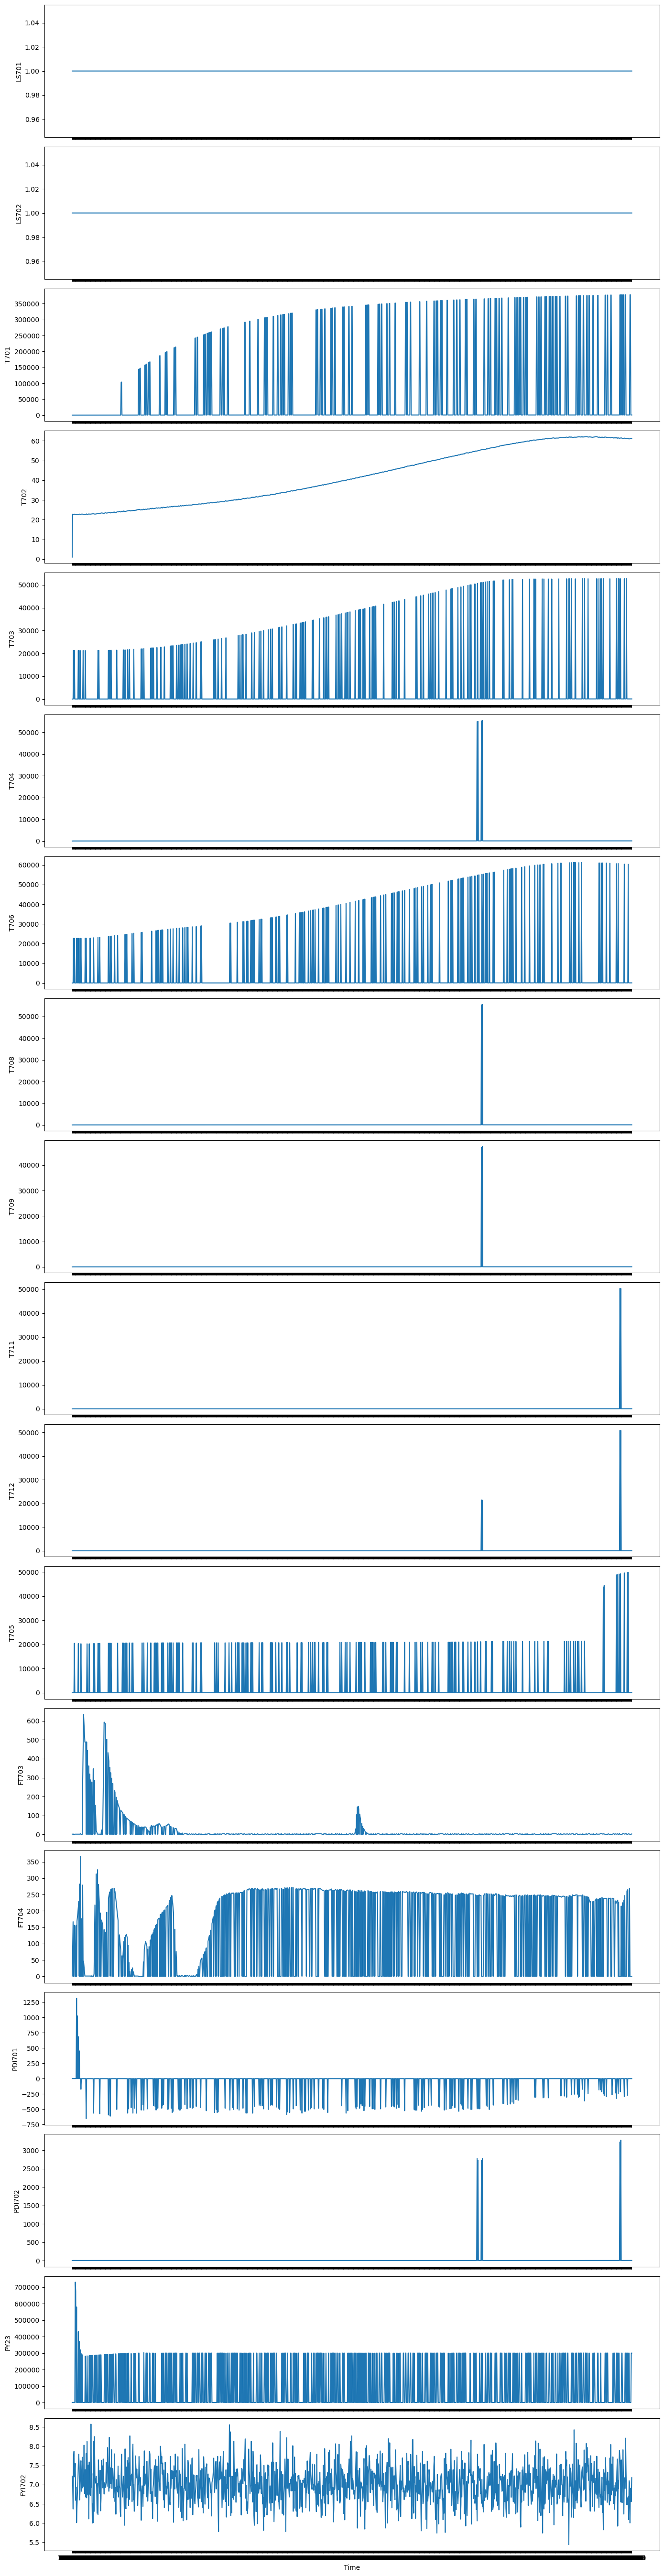

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'LS701', 'LS702',
    'T701', 'T702', 'T703', 'T704', 'T706', 'T708', 'T709', 'T711', 'T712', 'T705',
    'FT703', 'FT704',
    'PDI701', 'PDI702',
    'PY23', 'FYI702'
]

fig, axes = plt.subplots(
    nrows=len(features),
    ncols=1,
    figsize=(14, 3 * len(features)),
    sharex=True
)

for ax, feature in zip(axes, features):
    sns.lineplot(
        data=experiment,
        x="Time",
        y=feature,
        ax=ax
    )
    
    ax.set_ylabel(feature)
    ax.set_xlabel("")

axes[-1].set_xlabel("Time")

plt.tight_layout()
plt.show()

In [1]:
from pathlib import Path
import pandas as pd
import re


# -------------------------------------------------------------------------------------------------------------- #
#   PATHS
# -------------------------------------------------------------------------------------------------------------- #

DATA_DIR = Path("../data/raw")


# -------------------------------------------------------------------------------------------------------------- #
#   FUNCTION: GET FILE METADATA
# -------------------------------------------------------------------------------------------------------------- #

def get_file_metadata(target_folder):

    records = []

    folder = DATA_DIR / target_folder

    for csv_path in folder.rglob("*.csv"):

        path_str = str(csv_path)

        phase_match = re.search(
            r"(Startup|Operation|Shutdown)",
            path_str,
            re.IGNORECASE
        )

        batch_match = re.search(
            r"(batch_dist_binary_ethanol\+propan-2-ol|"
            r"batch_dist_ternary_acetone\+butan-1-ol\+methanol|"
            r"batch_dist_ternary_butan-1-ol\+propan-2-ol\+water)",
            path_str
        )

        operating_point_match = re.search(
            r"operating_point_(\d+)",
            path_str
        )

        experiment_match = re.search(
            r"(train_normal|test_anormal)_experiment_(\d+)",
            csv_path.stem
        )

        records.append({
            "file_name": csv_path.name,
            "source_folder": target_folder,
            "phase": phase_match.group(1) if phase_match else None,
            "batch": batch_match.group(1) if batch_match else None,
            "operating_point": (
                operating_point_match.group(0)
                if operating_point_match else None
            ),
            "experiment_type": (
                experiment_match.group(1)
                if experiment_match else None
            ),
            "experiment_number": (
                f"experiment_{experiment_match.group(2)}"
                if experiment_match else None
            ),
            "file_path": str(csv_path)
        })

    return pd.DataFrame(records)


# -------------------------------------------------------------------------------------------------------------- #
#   FUNCTION: LOAD TIME SERIES
# -------------------------------------------------------------------------------------------------------------- #

def load_timeseries(folder_name):

    df_files = get_file_metadata(folder_name)

    data = []

    for _, row in df_files.iterrows():

        df = pd.read_csv(row["file_path"])

        df["identifier"] = (
            row["phase"] + "/" +
            row["batch"] + "/" +
            row["operating_point"] + "/" +
            row["experiment_type"] + "/" +
            row["experiment_number"]
        )

        data.append(df)

    return pd.concat(data, ignore_index=True)


# -------------------------------------------------------------------------------------------------------------- #
#   LOAD ALL DATA
# -------------------------------------------------------------------------------------------------------------- #

anomalies_ts = load_timeseries(
    "00_Timeseries_Label_Anomaly_Metadata"
)

sensors_ts = load_timeseries(
    "01_Timeseries_Sensors"
)

actuators_ts = load_timeseries(
    "02_Timeseries_Actuators"
)


# -------------------------------------------------------------------------------------------------------------- #
#   ANOMALY LABEL
# -------------------------------------------------------------------------------------------------------------- #

anomalies_ts.loc[
    anomalies_ts["Time"].isna(),
    "Label (anomaly)"
] = 0

anomalies_ts = anomalies_ts.rename(
    columns={"Label (anomaly)": "anomaly_label"}
)


# -------------------------------------------------------------------------------------------------------------- #
#   MERGE DATA
# -------------------------------------------------------------------------------------------------------------- #

experiments = actuators_ts.merge(
    anomalies_ts[["identifier", "Time", "anomaly_label"]],
    on=["identifier", "Time"],
    how="left"
)

experiments["anomaly_label"] = (
    experiments["anomaly_label"].fillna(0)
)

experiments = sensors_ts.merge(
    experiments,
    on=["identifier", "Time"],
    how="left"
)

columns = [
    col
    for col in experiments.columns
    if col not in ["anomaly_label", "identifier"]
]

experiments = experiments[
    columns + ["anomaly_label", "identifier"]
]


# -------------------------------------------------------------------------------------------------------------- #
#   CREATE ELAPSED TIME
# -------------------------------------------------------------------------------------------------------------- #

experiments["Time_td"] = pd.to_timedelta(
    experiments["Time"]
)

experiments["time_diff"] = (
    experiments
    .groupby("identifier")["Time_td"]
    .diff()
)

# Known timestamp error
problem_identifier = (
    "Shutdown/"
    "batch_dist_ternary_butan-1-ol+propan-2-ol+water/"
    "operating_point_013/"
    "train_normal/"
    "experiment_001"
)

experiments["time_diff_clean"] = (
    experiments["time_diff"]
    .where(
        ~(
            (experiments["identifier"] == problem_identifier) &
            (experiments["time_diff"] < pd.Timedelta(0))
        ),
        pd.Timedelta(0)
    )
    .fillna(pd.Timedelta(0))
)

experiments["elapsed_time"] = (
    experiments
    .groupby("identifier")["time_diff_clean"]
    .cumsum()
    .dt.total_seconds()
)

experiments = experiments.drop(
    columns=[
        "Time_td",
        "time_diff",
        "time_diff_clean"
    ]
)

experiments.insert(
    experiments.columns.get_loc("Time") + 1,
    "elapsed_time",
    experiments.pop("elapsed_time")
)


# -------------------------------------------------------------------------------------------------------------- #
#   DECONSTRUCT IDENTIFIER
# -------------------------------------------------------------------------------------------------------------- #

identifier_parts = experiments["identifier"].str.split(
    "/",
    expand=True
)

identifier_parts.columns = [
    "phase",
    "batch",
    "operating_point",
    "experiment_type",
    "experiment"
]

experiments = pd.concat(
    [experiments.drop(columns="identifier"), identifier_parts],
    axis=1
)

experiments["anomaly_label"] = experiments.pop(
    "anomaly_label"
)


# -------------------------------------------------------------------------------------------------------------- #
#   CORRECT CORRUPTED VALUES
# -------------------------------------------------------------------------------------------------------------- #

columns_over_500 = [
    "T701", "T702", "T703", "T704", "T706",
    "T708", "T709", "T711", "T712", "T705",
    "PY23", "TV1", "H702", "H706", "H708",
    "H704", "P701", "P702"
]

columns_over_1 = [
    "FT703",
    "FT704",
    "PDI701",
    "PDI702"
]

for columns, threshold in [
    (columns_over_500, 500),
    (columns_over_1, 1)
]:

    mask = experiments[columns] > threshold

    experiments[columns] = (
        experiments[columns]
        .mask(mask, experiments[columns] / 1000)
    )

In [2]:
experiments

,Time,elapsed_time,LS701,LS702,T701,T702,T703,T704,T706,T708,...,AV716,TV1,P701,P702,phase,batch,operating_point,experiment_type,experiment,anomaly_label
0,14:00:32,0.0,1.0,0.0,25.700,25.80,23.90,25.30,25.8000,28.2000,...,1.0,0.0,0.00000,0.000000,Startup,batch_dist_ternary_butan-1-ol+propan-2-ol+water,operating_point_001,test_anormal,experiment_001,0.0
1,14:00:33,1.0,1.0,0.0,25.700,25.80,23.90,25.30,25.8000,28.2000,...,1.0,0.0,0.00000,0.000000,Startup,batch_dist_ternary_butan-1-ol+propan-2-ol+water,operating_point_001,test_anormal,experiment_001,0.0
2,14:00:34,2.0,1.0,0.0,25.700,25.80,23.90,25.30,25.8000,28.2000,...,1.0,0.0,0.00000,0.000000,Startup,batch_dist_ternary_butan-1-ol+propan-2-ol+water,operating_point_001,test_anormal,experiment_001,0.0
3,14:00:35,3.0,1.0,0.0,25.600,25.80,23.90,25.30,25.8000,28.2000,...,1.0,0.0,0.00000,0.000000,Startup,batch_dist_ternary_butan-1-ol+propan-2-ol+water,operating_point_001,test_anormal,experiment_001,0.0
4,14:00:36,4.0,1.0,0.0,25.700,25.80,23.90,25.30,25.9000,28.2000,...,1.0,0.0,0.00000,0.000000,Startup,batch_dist_ternary_butan-1-ol+propan-2-ol+water,operating_point_001,test_anormal,experiment_001,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1239331,17:02:55,7113.0,1.0,1.0,402.500,58.50,53.33,58.40,58.3600,58.3000,...,1.0,35.6,5.43625,5.546667,Operation,batch_dist_binary_ethanol+propan-2-ol,operating_point_002,train_normal,experiment_002,0.0
1239332,17:02:56,7114.0,1.0,1.0,402.250,58.35,53.30,58.35,58.3700,58.3000,...,1.0,35.5,5.48125,5.400000,Operation,batch_dist_binary_ethanol+propan-2-ol,operating_point_002,train_normal,experiment_002,0.0
1239333,17:02:57,7115.0,1.0,1.0,402.000,58.20,53.27,58.30,58.3800,58.3000,...,1.0,35.4,5.52625,5.253333,Operation,batch_dist_binary_ethanol+propan-2-ol,operating_point_002,train_normal,experiment_002,0.0
1239334,17:02:58,7116.0,1.0,1.0,402.067,58.20,53.26,58.30,58.3667,58.3333,...,1.0,23.6,5.81875,4.177333,Operation,batch_dist_binary_ethanol+propan-2-ol,operating_point_002,train_normal,experiment_002,0.0
